In [1]:
import pandas as pd
import json

In [2]:
file = "../data/external/first_100_selected_examples_without_docstrings_base_model_og_prompt_V2_instruct_comparison_with_position_info_post_process.json"

In [3]:
def create_input_prompt_prefix(task_prompt, test_list, mode = "base"):
    prompt = (
            "You are an expert Python programmer, and here is your task: "
            f"{task_prompt} Your code should pass these tests:\n\n"
            + "\n".join(test_list) + "\nWrite your code below starting with \"```python\" and ending with \"```\".\n```python\n"
        )
    if mode == "instruct":
        prompt = (
            "You are an expert Python programmer, and here is your task: "
            f"{task_prompt} Your code should pass these tests:\n\n"
            + "\n".join(test_list) + "\nWrite your code, without docstrings, below starting with \"```python\" and ending with \"```\".\n```python\n"
        )
    
    return prompt

In [4]:
import ast

class Normalizer(ast.NodeTransformer):
    def __init__(self):
        self.var_map = {}
        self.func_map = {}
        self.class_map = {}
        self.counter = 0

    def _rename(self, name, mapping):
        if name not in mapping:
            mapping[name] = f"id_{len(mapping)}"
        return mapping[name]

    def visit_Name(self, node):
        node.id = self._rename(node.id, self.var_map)
        return node

    def visit_arg(self, node):
        node.arg = self._rename(node.arg, self.var_map)
        return node

    def visit_FunctionDef(self, node):
        node.name = self._rename(node.name, self.func_map)
        self.generic_visit(node)
        return node

    def visit_ClassDef(self, node):
        node.name = self._rename(node.name, self.class_map)
        self.generic_visit(node)
        return node

def normalize(code):
    try:
        tree = ast.parse(code)
        normalized = Normalizer().visit(tree)
        return ast.dump(normalized, annotate_fields=True, include_attributes=False)
    except:
        return None

In [5]:
def check_if_abstract_tree_same(base_response, instruct_response):
    return normalize(base_response) == normalize(instruct_response)

In [6]:
import difflib

def similarity(code1, code2):
    return difflib.SequenceMatcher(None, code1, code2).ratio()

In [7]:
sample_base_response = "def sum_series(n):\n    return n - 2 * (n // 2)"
sample_instruct_response = "def sum_series(n):\n  total = 0\n  for i in range(n // 2):\n    total += n - 2 * i\n  return total\n"

In [8]:
def _extract_code_part(input_prefix_text, suffix_text):
    full_text = input_prefix_text + suffix_text
    return "def" + full_text.split("```python\n")[-1].split("def")[1]

def _ascertain_two_codes_similar(expected_code, steered_code, threshold = 0.95, verbose = False):
    normalized_expected_code = normalize(expected_code)
    normalized_steered_code = normalize(steered_code)
    if verbose:
        print("Check for full similarity", normalized_expected_code == normalized_steered_code)
        print("Check for whether crosses threshold", similarity(normalized_expected_code, normalized_steered_code))
    return normalized_expected_code == normalized_steered_code or similarity(normalized_expected_code, normalized_steered_code) > threshold

In [9]:
_ascertain_two_codes_similar(sample_base_response, sample_instruct_response)

False

In [10]:
sample_base_response = "def sum_series(n):\n    return n - 2 * func(n - 2)"
alt_base_response = """def sum_series(m):\n    return m ** 0.5 - 2 * func (m // 2)"""
_ascertain_two_codes_similar(sample_base_response, alt_base_response, verbose = True)

Check for full similarity False
Check for whether crosses threshold 0.9375


False

In [11]:
sample_base_response = """
def sum_series(n):
    sum = 0
    for i in range(5):
        sum += i
    return sum
"""
alt_base_response = """
def sum_ser(b):
    s = 0
    for i in range(0, 5):
        s = s + i
    return s
"""
_ascertain_two_codes_similar(sample_base_response, alt_base_response, verbose = True)

Check for full similarity False
Check for whether crosses threshold 0.6421232876712328


False

### Use the Zhang-ShaSha distance of actual similarity based on some threshold.
-- https://zhang-shasha.readthedocs.io/en/latest/

In [12]:
from zss import simple_distance, Node

def to_zss(node):
    if not isinstance(node, ast.AST):
        return None
    children = []
    for f in node._fields:
        value = getattr(node, f)
        if isinstance(value, list):
            for child in value:
                if isinstance(child, ast.AST):
                    children.append(to_zss(child))
        elif isinstance(value, ast.AST):
            children.append(to_zss(value))
    return Node(node.__class__.__name__, children=children)

In [13]:
def normalize_ast(code):
    try:
        tree = ast.parse(code)
        norm = Normalizer().visit(tree)
        ast.fix_missing_locations(norm)
        return norm
    except Exception as e:
        return None

In [14]:
def print_ast(node, indent=""):
    print(indent + node.__class__.__name__)
    for child in ast.iter_child_nodes(node):
        print_ast(child, indent + "  ")

def visualize_ast(code):
    tree = ast.parse(code)
    print_ast(tree)

In [15]:
def _check_zss_sim(code1, code2, threshold = 4, verbose = False):
    node1 = normalize_ast(code1)
    node2 = normalize_ast(code2)
    distance = simple_distance(to_zss(node1), to_zss(node2))
    if verbose:
        print("Check for distance", distance)
    return distance <= 4

In [16]:
_check_zss_sim(sample_base_response, alt_base_response, verbose = True)

Check for distance 5.0


False

In [17]:
visualize_ast(sample_base_response)

Module
  FunctionDef
    arguments
      arg
    Assign
      Name
        Store
      Constant
    For
      Name
        Store
      Call
        Name
          Load
        Constant
      AugAssign
        Name
          Store
        Add
        Name
          Load
    Return
      Name
        Load


In [18]:
sample_base_response = "def sum_series(n):\n    return n - 2 * (n // 2)"
sample_instruct_response = "def sum_series(n):\n  total = 0\n  for i in range(n // 2):\n    total += n - 2 * i\n  return total\n"
_check_zss_sim(sample_base_response, sample_instruct_response, verbose = True)

Check for distance 25.0


False

In [19]:
visualize_ast(sample_base_response)

Module
  FunctionDef
    arguments
      arg
    Return
      BinOp
        Name
          Load
        Sub
        BinOp
          Constant
          Mult
          BinOp
            Name
              Load
            FloorDiv
            Constant


In [20]:
sample_base_response = """
def sum_series(n):
    sum = 0
    for i in range(5):
        sum += i
    return sum
"""
alt_base_response = """
def sum_ser(b):
    s = 0
    for i in range(0, 5):
        s = s + i
    return s
"""
_check_zss_sim(sample_base_response, alt_base_response, verbose = True)

Check for distance 5.0


False

In [21]:
sample_base_response = """
def sum_series(n):
    sum = 0
    for i in range(5):
        sum += i
    return sum
"""
alt_base_response = """
def sum_ser(b):
    s = 0
    for i in range(5):
        s += i
    return s
"""
_check_zss_sim(sample_base_response, alt_base_response, verbose = True)

Check for distance 0.0


True

In [22]:
sample_base_response = "def sum_series(n):\n    return n - 2 * (n // 2)"
alt_base_response = "def sum_series(n):\n    return n - 3 * (n // 3)"
_check_zss_sim(sample_base_response, alt_base_response, verbose = True)

Check for distance 0.0


True

In [23]:
sample_base_response = """
def format_string(list_of_string, intended_format):
    t_string = []
    for i in range(len(list_of_string)):
        t_string.append(list_of_string[i].format(intended_format))
    return t_string
"""
alt_base_response = """
def format_string(b_list, b_format):
    return [u.format(b_format) for u in b_list]
"""
_check_zss_sim(sample_base_response, alt_base_response, verbose = True)

Check for distance 29.0


False

In [24]:
sample_base_response = """
def format_string(list_of_string, intended_format):
    return [list_of_string[i].format(intended_format) for i in range(len(list_of_string))]
"""
alt_base_response = """
def format_string(b_list, b_format):
    return [u.format(b_format) for u in b_list]
"""
_check_zss_sim(sample_base_response, alt_base_response, verbose = True)

Check for distance 10.0


False

In [25]:
sample_base_response = """
def tetrahedral_number(n):
    return (n * (n + 1) * (n + 2)) // 6
"""
alt_base_response = """
def tetrahedral_number(n):
    return 1 + 2 * (n - 1) 
"""
_check_zss_sim(sample_base_response, alt_base_response, verbose = True)

Check for distance 12.0


False

In [26]:
sample_base_response = """
def tetrahedral_number(n):
    return (n * (n + 1) * (n + 2)) // 6
"""
alt_base_response = """
def tetrahedral_number(n):
    return (2 * n * (n + 1) * (n + 2)) // 3
"""

_check_zss_sim(sample_base_response, alt_base_response, verbose = True)
_ascertain_two_codes_similar(sample_base_response, alt_base_response, verbose = True)

Check for distance 3.0
Check for full similarity False
Check for whether crosses threshold 0.952561669829222


True

In [27]:
sample_base_response = """
def tetrahedral_number(n):
    return (n * (n + 1) * (n + 2)) // 6
"""
alt_base_response = """
def tetrahedral_number(n):
    return n * (2 * n + 1) * (n + 2) / 6
"""

_check_zss_sim(sample_base_response, alt_base_response, verbose = True)
_ascertain_two_codes_similar(sample_base_response, alt_base_response, verbose = True)

Check for distance 4.0
Check for full similarity False
Check for whether crosses threshold 0.9494756911344138


False

In [28]:
sample_base_response = """
def tetrahedral_number(n):
    return (n * (n + 1) * (n + 2)) // 6
"""
alt_base_response = """
def tetrahedral_number(n):
    return n * (2 * n + 1) * (n + 2) / 6
"""

_check_zss_sim(sample_base_response, alt_base_response, verbose = True)
_ascertain_two_codes_similar(sample_base_response, alt_base_response, verbose = True)

Check for distance 4.0
Check for full similarity False
Check for whether crosses threshold 0.9494756911344138


False

In [29]:
from zss import simple_distance, Node

def _check_zss_sim_with_ops(code1, code2, threshold=4, verbose=False):
    node1 = normalize_ast(code1)
    node2 = normalize_ast(code2)
    
    tree1 = to_zss(node1)
    tree2 = to_zss(node2)
    
    # Get distance with operations
    result = simple_distance(
        tree1, tree2,
        get_children=lambda n: n.children if hasattr(n, 'children') else [],
        get_label=lambda n: n.label if hasattr(n, 'label') else str(type(n).__name__),
        label_dist=lambda a, b: 0 if a == b else 1,
        return_operations=True
    )
    
    if isinstance(result, tuple):
        dist, ops = result
    else:
        dist = result
        ops = []
    
    if verbose:
        print(f"Distance: {dist}\n")
        
        for i, op in enumerate(ops):
            op_type = str(type(op).__name__)
            
            if hasattr(op, 'arg1') and hasattr(op, 'arg2'):
                node1 = getattr(op.arg1, 'label', op.arg1)
                node2 = getattr(op.arg2, 'label', op.arg2)
                print(f"{i:3d}: {op_type:8s} {node1} -> {node2}")
            elif hasattr(op, 'arg1'):
                node1 = getattr(op.arg1, 'label', op.arg1)
                print(f"{i:3d}: {op_type:8s} {node1}")
            elif hasattr(op, 'arg2'):
                node2 = getattr(op.arg2, 'label', op.arg2)
                print(f"{i:3d}: {op_type:8s} {node2}")
    
    return dist <= threshold, ops

In [30]:
_check_zss_sim_with_ops(sample_base_response, alt_base_response)

(True,
 [<Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Insert>,
  <Operation Match>,
  <Operation Match>,
  <Operation Insert>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Update>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>,
  <Operation Match>])

### Exercise.
- Tuning the hyperparameters here. - \{lambda} and \{gamma}.
- 15 examples of triples - `(base, steered, complement)` - whether it's okay to say that the model output has steered.
- tune the params on 10 examples and see if that generalizes for the remaining 5.

### How to:
- Create `categorization_module_data.json` with entries which contain `model_code`, `complement_code`, `steered_code` and a label which is just False right now.
- This is created using data pulled from entries, then looking at plans and then pulling the closest (in terms of zss_distance) to complement code.
- do this for 25 prompt with `model_code` as base or instruct, then we have 50 entries.
- label each manually.
- now, we tune the parameters.

In [31]:
def _get_zss_sim(code1, code2):
    node1 = normalize_ast(code1)
    node2 = normalize_ast(code2)
    try:
        distance = simple_distance(to_zss(node1), to_zss(node2))
        return distance
    except:
        print("got exception for ", code1, code2)
        return 30

In [32]:
def _get_all_valid_steers(file, y_ms):
    with open(file, "r") as f:
        data = json.load(f)
    meta_file = file.replace("steering_results.json", "metadata.json")
    with open(meta_file, "r") as f:
        meta_data = json.load(f)
        input_prefix = meta_data["input_prefix_text"]
    all_valid_steers = []
    for cand, val in data.items():
        if cand in y_ms:
            for steer in val["steered"]:
                if "decoded_text" in steer:
                    decoded_text = steer["decoded_text"]
                    extracted_code = _extract_code_part(input_prefix, decoded_text)
                    all_valid_steers.append(extracted_code)
    
    return all_valid_steers

In [33]:
file_path = "../outputs/scale-exp/base/prompt_0/token_114/steering_results.json"
_get_all_valid_steers(file_path, ["in"])

['def is_not_prime(number):\n',
 'def is_not_prime(number):\nif number % 2 == 0:\nreturn False\nelse:\nreturn True\n',
 'def is_not_prime(number):\n']

In [34]:
import json
import glob

source_data_file = "../data/external/first_100_selected_examples_without_docstrings_base_model_og_prompt_V2_instruct_comparison_with_position_info_post_process.json"
categorization_file = "../data/custom/categorization_module_data.json"

with open(source_data_file, "r") as f:
    source_data = json.load(f)

def obtain_min(objects, scores):
    objects, scores = zip(*sorted(zip(objects, scores), key=lambda x: x[1]))
    objects = list(objects)
    scores = list(scores)
    return objects[0], scores[0]

def _curate_entry(base, steer, complement, idx, tag = "base to instruct"):
    return {
        "model_code": base,
        "steered_code": steer,
        "complement_code": complement,
        "entry_idx": idx,
        "tag": tag,
        "label": False
    }

curated_entries = []

for idx, entry in enumerate(source_data):
    ## if instruct and base both plan, then, we get the nearest steers.
    ym_bases, ym_instructs = entry["base_plans"], entry["instruct_plans"]
    actual_base_code, actual_instruct_code = entry["model_output"], entry["instruct_code"]
    if ym_bases is not None and ym_instructs is not None and len(ym_bases) > 0 and len(ym_instructs) > 0:
        base_token_files = glob.glob(f"../outputs/scale-exp/base/prompt_{idx}/token_*/*steering*json")
        instruct_token_files = glob.glob(f"../outputs/scale-exp/instruct/prompt_{idx}/token_*/*steering*json")

        ## get the metainput here and then parse the output, chill....
        all_base_steers = [_get_all_valid_steers(token_file, ym_bases) for token_file in  base_token_files]
        all_base_steers = [x for sub in all_base_steers for x in sub]
        all_instruct_steers = [_get_all_valid_steers(token_file, ym_instructs) for token_file in instruct_token_files]
        all_instruct_steers = [x for sub in all_instruct_steers for x in sub]

        ## find the closest base to instruct and closest instruct to base steer.   
        base_steer_zss = [_get_zss_sim(code, actual_instruct_code) for code in all_base_steers]
        instruct_steer_zss = [_get_zss_sim(code, actual_base_code) for code in all_instruct_steers]
        closest_base_steer, base_steer_val = obtain_min(all_base_steers, base_steer_zss)
        closest_instruct_steer, instruct_steer_val = obtain_min(all_instruct_steers, instruct_steer_zss)

        entry_base = _curate_entry(actual_base_code, closest_base_steer, actual_instruct_code, idx)
        entry_instruct = _curate_entry(actual_instruct_code, closest_instruct_steer, actual_base_code, idx, tag = "instruct to base")
        curated_entries.append(entry_base)
        curated_entries.append(entry_instruct)

with open(categorization_file, "w") as f:
    json.dump(curated_entries, f, indent = 4)

got exception for  def check(onemore):
    if onemore % 7 == 0:
        return True
    return False
print(check(7))
print(check(23))
print(check(73))
print(check(77))
print(check(777))
print(check(7777))
print(check(77777))
print(check(777777))
print(check def check(n):
  return n == 2 * int(str(n)[::-1]) - 1

got exception for  def check( number ):
    if number % 7 == 0:
        return True
    else:
        return False
print( check(70) )
print( check(23) )
print( check(73) )
print( check(77) )
print( check(17) )
print( check(11) )
print( check(1) )
print( check(0) )
print( check( def check(n):
  return n == 2 * int(str(n)[::-1]) - 1

got exception for  def check(n 10 seconds)
 def check(n):
  return n == 2 * int(str(n)[::-1]) - 1

got exception for  def check(n) { return n == 23; }
assert check(23) == True
assert check(23) == True
assert check(23) == True
assert check(23) == True
assert check(23) == True
assert check(23) == True
assert check(23) == True
assert check(23) == True
as

In [35]:
# import shutil

# shutil.copy(categorization_file, categorization_file.replace("data.json", "data_manual_label.json"))

In [36]:
## smallest lamda and gamma that satisfies the true and false accurately.
categorization_file_with_label = "../data/custom/categorization_module_data_manual_label.json"
with open(categorization_file_with_label, "r") as f:
    label_data = json.load(f)

    # return {
    #     "model_code": base,
    #     "steered_code": steer,
    #     "complement_code": complement,
    #     "entry_idx": idx,
    #     "tag": tag,
    #     "label": False
    # }

def _steered_answer_goes_closer_to_complement(current_generation, steered_generation, complement_generation, gamma = 0.5, lamda = 8):
    try:
        current_code = normalize_ast(current_generation)
        steered_code = normalize_ast(steered_generation)
        complement_code = normalize_ast(complement_generation)
        d_orig = simple_distance(to_zss(current_code), to_zss(complement_code))
        d_new = simple_distance(to_zss(steered_code), to_zss(complement_code))
        if isinstance(d_orig, float) and isinstance(d_new, float):
            d_ratio = (d_new + 1) / (d_orig + 1)
            # print("d_ratio", d_ratio, "d_new", d_new)
            return d_ratio <= gamma and d_new <= lamda, d_ratio, d_new
    except:
        pass
    return False, 1, 30

for idx, c_entry in enumerate(label_data):
    expected_label = c_entry["label"]
    calculated_label, d_ratio, d_new = _steered_answer_goes_closer_to_complement(c_entry["model_code"], c_entry["steered_code"], c_entry["complement_code"])
    if expected_label != calculated_label:
        print("expected_label", expected_label, "calculated_label", calculated_label)
        print("Wrong at entry ", idx)
        print(c_entry)
        print("New distance and distance ratio", d_ratio, d_new)

### found what?
- in 8 out of 28 cases where both instruct and base were planning, we could see that a steered answer from instruct existed in base as well.

In [37]:
original_data_file = "../data/external/first_100_selected_examples_without_docstrings_base_model_og_prompt_V2_instruct_comparison_with_position_info_post_process.json"
categorization_file_with_label = "../data/custom/categorization_module_data_manual_label.json"

with open(original_data_file, "r") as f:
    original_data = json.load(f)

with open(categorization_file_with_label, "r") as f:
    categorization_data = json.load(f)

In [38]:
info = {}

for idx, entry in enumerate(categorization_data):
    see_idx = entry["entry_idx"]
    base_pass = original_data[see_idx]["base_pass"]
    label = entry["label"]
    if see_idx not in info or label == True:
        info[see_idx] = {
            "base_pass": base_pass,
            "label": label
        }

In [39]:
len(list(info.keys()))

28

In [40]:
import pandas as pd

def _get_2x2_matrix(info):
    rows = info.values()
    df = pd.DataFrame(rows)
    matrix = pd.crosstab(df['base_pass'], df['label'])
    print(matrix)

In [41]:
_get_2x2_matrix(info)

label      False  True 
base_pass              
False          4      3
True          16      5


In [42]:
for idx, entry in enumerate(categorization_data):
    entry["base_pass"] = info[entry["entry_idx"]]["base_pass"]

In [43]:
with open(categorization_file_with_label, "w") as f:
    json.dump(categorization_data, f, indent = 4)

### what we can say now.
- only in some cases, we can definitively prove that that either the base or instruct answers exist in each other subspaces. => in only 3 out of 7 cases where the base model fails.
- This is A1 + A2 vs. A3, so roughly a third of A can be definitively proved as an "improvement in planning behaviour"

In [44]:
def plot_rule_boundary(X, y, lam, gamma, texts):
    """
    Visualize decision boundary for rule:
        label = 1 if f1 <= lam and f2 <= gamma, else 0

    X: (N,2) np.array
    y: (N,) labels
    lam: threshold for feature 1
    gamma: threshold for feature 2
    """
    import numpy as np
    import matplotlib.pyplot as plt

    f1 = X[:,0]
    f2 = X[:,1]

    plt.figure(figsize=(7,6))

    # Plot points
    plt.scatter(f1, f2, c=y, s=40, edgecolor='k')

    # Draw rule boundaries
    plt.axvline(lam, color='red', linestyle='--', label=f"f1 = {lam}")
    plt.axhline(gamma, color='blue', linestyle='--', label=f"f2 = {gamma}")

    # Fill the accepted (label=1) decision region (optional)
    plt.axvspan(f1.min()-1, lam, ymin=0, ymax=(gamma - f2.min())/(f2.max()-f2.min()),
                alpha=0.1, color='red')

    # plt.xlabel("Feature 1 (f1)")
    # plt.ylabel("Feature 2 (f2)")
    # plt.title("Rule-based Decision Boundary")

    plt.xlabel(texts[0])
    plt.ylabel(texts[1])
    plt.title(texts[2])
    plt.legend()
    plt.tight_layout()
    plt.show()

In [45]:
categorization_data[0]

{'model_code': 'def check(n):\n    if n == 0:\n        return False\n    if n < 0:\n        n = -n\n    rev = 0\n    while n > 0:\n        rev = rev * 10 + n % 10\n        n = n // 10\n    if n == 0:\n        return True\n    if n == rev - 1:\n        return True\n    return False',
 'steered_code': 'def check(n):\n  return n == 2 * int(str(n)[::-1]) - 1\n',
 'complement_code': 'def check(n):\n  return n == 2 * int(str(n)[::-1]) - 1\n',
 'entry_idx': 2,
 'tag': 'base to instruct',
 'label': True,
 'base_pass': False}

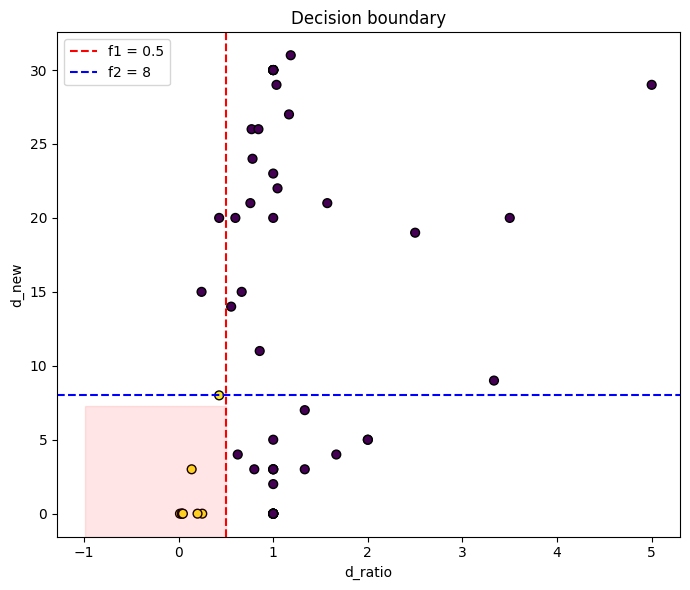

In [46]:
x = [] ## get the d_ratio and d_new values here.
y = [] ## get the label here 0 / 1


for c_entry in categorization_data:
    _, d_ratio, d_new = _steered_answer_goes_closer_to_complement(c_entry["model_code"], c_entry["steered_code"], c_entry["complement_code"])
    x.append((d_ratio, d_new))
    y.append(1 if c_entry["label"] else 0)

import numpy as np

x = np.array(x)
y = np.array(y)
plot_rule_boundary(x, y, 0.5, 8, ("d_ratio", "d_new", "Decision boundary"))